Using the typing dataset (lightgbm) from that was label encoded duing preprocessing

In [39]:
#Importing dependencies and modules

import pandas as pd
import sklearn 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [40]:
df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/Typing dataset/modeling.csv")

In [41]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,UPDRS,Gender_Male,Ratio,Latency-HoldTime
0,0,101.6,0,234.4,156.3,True,0,False,0.650032,132.8
1,0,78.1,0,210.9,125.0,True,0,False,0.624800,132.8
2,1,85.9,1,195.3,117.2,True,0,False,0.732935,109.4
3,1,78.1,1,203.1,171.9,True,0,False,0.454334,125.0
4,0,78.1,0,203.1,132.8,True,0,False,0.588102,125.0
...,...,...,...,...,...,...,...,...,...,...
1400379,1,132.8,3,320.3,156.3,True,0,False,0.849648,187.5
1400380,1,117.2,3,281.3,210.9,True,0,False,0.555714,164.1
1400381,1,140.6,3,328.1,156.3,True,0,False,0.899552,187.5
1400382,1,109.4,3,203.1,93.8,True,0,False,1.166311,93.7


In [42]:
#Dropping the unmaned column right away
#df = df.drop(columns= "Unnamed: 0")

In [43]:
for col in df.columns:
    print(df[col].unique())

[0 1]
[101.6  78.1  85.9  93.8 109.4 117.2 140.6 125.  128.9 121.1  89.8  82.
  97.7 113.3 138.7 111.3  74.2 105.5 132.8 136.7  87.9  99.6  80.1  76.2
  95.7  91.8 140.   90.8 107.4 103.5 115.2  84.   94.7 119.1  90.   77.1
  81.1 130.9 141.6 108.9 127.  127.9 143.6 112.3 110.4 124.  106.4 122.1
 142.6 129.9 139.6 126.  114.3 131.8 134.8  98.6 140.1 123.  120.1 137.7
 116.2 116.9 116.  135.  132.  131.  103.  133.9 117.1 121.  101.  121.9
 100.  120.   98.  100.1 143.1 129.  107.1 131.1 101.1 142.  132.1 119.
 128.2 106.9  86.9  99.9  92.8 144.   95.  111.9  96.2 128.4  79.6 104.
  79.1 104.5  96.7 135.7  88.9 108.4 136.   83.  102.5 100.6  85.  131.3
 115.7 114.7 105.  107.9  91.3  75.2 118.2  96.9  88.1 101.8  87.2 133.8
 108.  102.   77.  133.1 113.  102.1  79.8  98.1 114.   94.   93.  142.1
 110.8 135.3  96.  122.   92.  106.   75.  133.3 111.8  94.2 112.8 109.9
 136.2 113.8 132.3  75.7  99.1 141.1  93.3  73.7 134.3 129.4 130.4  87.
 110.  142.9  89.1 107.2 137.   75.9  86.2  77.9 

In [44]:
df["Parkinsons"].value_counts()

Parkinsons
True     927687
False    472697
Name: count, dtype: int64

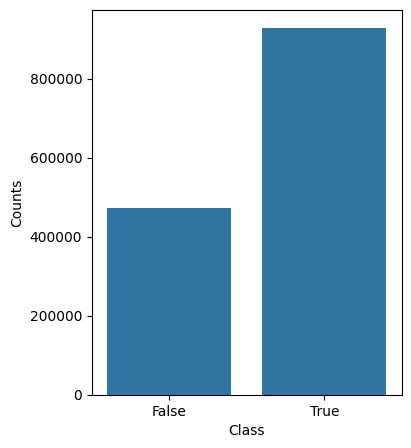

In [45]:
#Visualizations 

class_counts = np.bincount(df["Parkinsons"])

plt.figure(figsize=(4,5))
sns.barplot(x = np.unique(df["Parkinsons"]), y=class_counts)
plt.xlabel("Class")
plt.ylabel("Counts")
plt.show()

In [46]:
#Importing modules
from sklearn.model_selection import train_test_split
import lightgbm as lgb

In [47]:
#Defining the features and labels for dataset 
y = df["Parkinsons"]

X = df.drop(columns=["Parkinsons", "Gender_Male", "Hand", "Direction"])

In [48]:
#Oversampling the minority class in PD
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Assume X and y are your features and labels
print("Original class distribution:", Counter(y))

rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled class distribution:", Counter(y_resampled))

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, random_state=42, test_size=0.3)



Original class distribution: Counter({True: 927687, False: 472697})


/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Resampled class distribution: Counter({False: 472697, True: 472697})


In [49]:
print(X_train.columns.tolist())

['HoldTime', 'LatencyTime', 'FlightTime', 'UPDRS', 'Ratio', 'Latency-HoldTime']


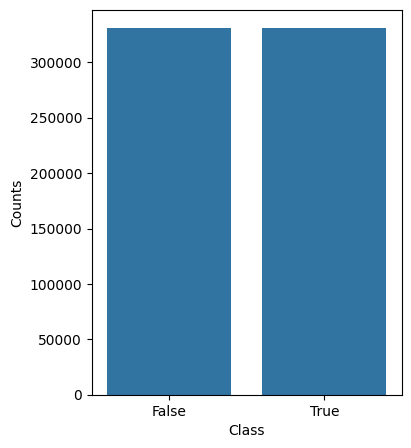

In [50]:
#Visualizations of the PD class after SMOTE
import numpy as np
class_counts = np.bincount(y_train)

plt.figure(figsize=(4, 5))
sns.barplot(x = np.unique(y_train), y=class_counts)
plt.xlabel("Class")
plt.ylabel("Counts")
plt.show()

In [51]:
#Balancing weights

from sklearn.utils import compute_class_weight
import numpy as np

weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights))



In [52]:
#Defining hyperparameters in dict-like form

model_lgbm = lgb.LGBMClassifier(objective= "binary",
    num_leaves = 30,
    class_weight = class_weight_dict,
    force_col_wise = True,
    max_depth = 6,
    n_estimators= 100,
    learning_rate = 0.1)

In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [54]:
#Fitting the model, training and performing evaluation

model_lgbm.fit(X_train, y_train)

model_lgbm.predict_proba(X_test)

pred = model_lgbm.predict(X_test)

score = model_lgbm.score(X_train, y_train)

acc_score = accuracy_score(y_test, pred)


In [55]:
acc_score

0.6336952037768979

In [56]:
print("Accuracy on the train set", score)

print("Accuracy on the test set", model_lgbm.score(X_test, y_test))

Accuracy on the train set 0.6352763401458199
Accuracy on the test set 0.6336952037768979


In [ ]:
#Confusion matrix and classification matrix
cm = confusion_matrix(y_test, pred)
print(cm)

class_report = classification_report(y_test, pred)
print(class_report)

[[95184 46627]
 [57264 84544]]


<Axes: title={'center': 'Plot of feature importance'}, xlabel='Feature importance', ylabel='Features'>

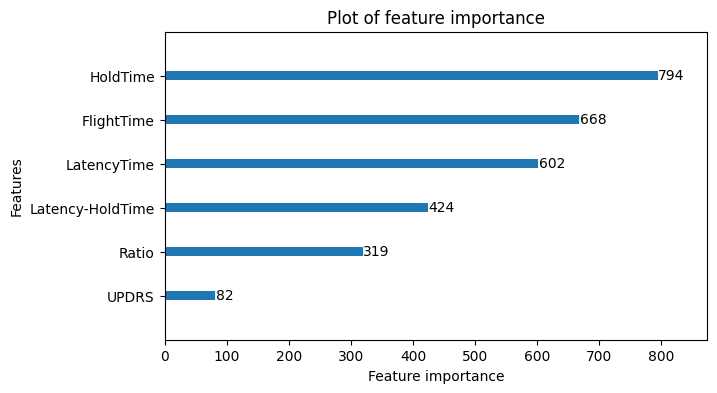

In [ ]:
#Plotting important features
lgb.plot_importance(model_lgbm, title="Plot of feature importance", figsize=(7,4), grid=False )

In [ ]:
model_lgbm.feature_importances_

array([794, 602, 668,  82, 319, 424], dtype=int32)

Text(0.5, 1.0, 'ROC plot')

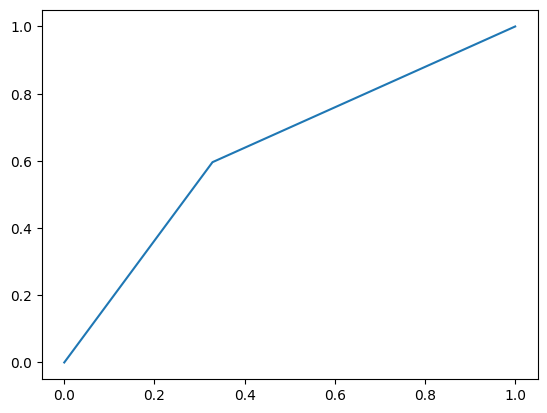

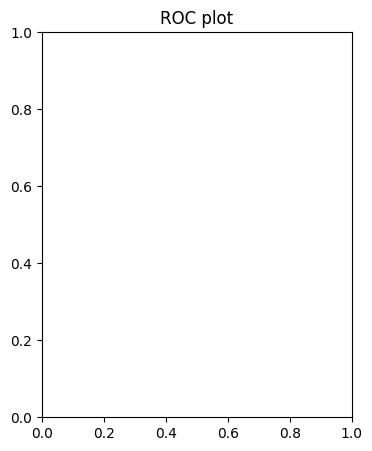

In [ ]:
#Plotting roc-curve

from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, pred)

sns.lineplot(x=fpr, y=tpr)

plt.figure(figsize=(4,5))

plt.title("ROC plot")

Retraining the model with only the most impactful features, so dropping hand and direction

In [ ]:
df_new = df.drop(columns = ["Hand", "Gender_Male"])

In [ ]:
df_new

,HoldTime,LatencyTime,FlightTime,Parkinsons,UPDRS,Ratio,Latency-HoldTime
0,101.6,234.4,156.3,True,0,0.650032,132.8
1,78.1,210.9,125.0,True,0,0.624800,132.8
2,85.9,195.3,117.2,True,0,0.732935,109.4
3,78.1,203.1,171.9,True,0,0.454334,125.0
4,78.1,203.1,132.8,True,0,0.588102,125.0
...,...,...,...,...,...,...,...
1400379,132.8,320.3,156.3,True,0,0.849648,187.5
1400380,117.2,281.3,210.9,True,0,0.555714,164.1
1400381,140.6,328.1,156.3,True,0,0.899552,187.5
1400382,109.4,203.1,93.8,True,0,1.166311,93.7


In [ ]:
#Defining labels and features, and input vectors
from imblearn.over_sampling import SMOTE

y_final = df_new["Parkinsons"]

X_final = df_new.drop(columns=["Parkinsons"])

X_train_new, X_test_final, y_train_new, y_test_final = train_test_split(X_final, y_final, random_state=42, test_size=0.2)

smote_final = SMOTE(random_state = 42)

X_train_final, y_train_final = smote_final.fit_resample(X_train_new, y_train_new)

/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [ ]:
print("Train columns:", X_train_final.columns.tolist())
print("Test columns:", X_test_final.columns.tolist())

Train columns: ['HoldTime', 'LatencyTime', 'FlightTime', 'UPDRS', 'Ratio', 'Latency-HoldTime']
Test columns: ['HoldTime', 'LatencyTime', 'FlightTime', 'UPDRS', 'Ratio', 'Latency-HoldTime']


In [ ]:
model_final = lgb.LGBMClassifier(objective= "binary",
    num_leaves = 30,
    force_col_wise = True,
    max_depth = 6,
    n_estimators= 100,
    learning_rate = 0.5, verbose=-1)

In [ ]:
#Fitting the model, evaluating the model, 
model_final.fit(X_train_final, y_train_final)

final_pred = model_final.predict(X_test_final)

score_final = model_final.score(X_train_final, y_train_final)


In [ ]:
#Printing the evalutaion metrics
print(accuracy_score(y_test_final, final_pred))
print()

print(confusion_matrix(y_test_final, final_pred))
print()

print(classification_report(y_test_final, final_pred))
print()

0.6341648903694341

[[ 63261  31528]
 [ 70934 114354]]

              precision    recall  f1-score   support

       False       0.47      0.67      0.55     94789
        True       0.78      0.62      0.69    185288

    accuracy                           0.63    280077
   macro avg       0.63      0.64      0.62    280077
weighted avg       0.68      0.63      0.64    280077




Hyperparameter tuning with RandomizedSearchCV since the dataset is large 

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, KFold

In [ ]:
#Cross validation 
kfold = KFold(n_splits=5, random_state = 42, shuffle=True)

param_grid = {
    "num_leaves": np.arange(20,80,10).tolist(),
    "max_depth": np.arange(4, 12, 4).tolist(),
    "learning_rate": [0.01, 0.05, 0.1],
    "feature_fraction": [0.7, 0.8,0.9],
    "bagging_fraction":[0.7, 0.8, 0.9],
    "min_child_samples": [10, 20, 50],
    "min_split_gain": [0.0, 0.01, 0.1],

}

grid = RandomizedSearchCV(estimator=model_final, param_distributions=param_grid, cv=kfold)

In [ ]:
grid.fit(X_train_final, y_train_final)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=LGBMClassifier(force_col_wise=True,
                                            learning_rate=0.5, max_depth=6,
                                            num_leaves=30, objective='binary',
                                            verbose=-1),
                   param_distributions={'bagging_fraction': [0.7, 0.8, 0.9],
                                        'feature_fraction': [0.7, 0.8, 0.9],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 8],
                                        'min_child_samples': [10, 20, 50],
                                        'min_split_gain': [0.0, 0.01, 0.1],
                                        'num_leaves': [20, 30, 40, 50, 60, 70]})

In [ ]:
#Pulling the best hyperparamters

grid_best = grid.best_params_
grid.best_score_

0.6473284577751707

In [ ]:
#Training new model based on hyperparamters from RSCV

model =  lgb.LGBMClassifier(objective= "binary",
    num_leaves = grid_best["num_leaves"],
    min_split_gain = grid_best["min_split_gain"],
    min_child_samples = grid_best["min_child_samples"],
    force_col_wise = True,
    max_depth = grid_best["max_depth"],
    learning_rate = grid_best["learning_rate"],
    feature_fraction = grid_best["feature_fraction"],
    bagging_fraction = grid_best["bagging_fraction"],
    n_estimators= 100)

In [ ]:
#Fitting and making predictions on test data
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print(accuracy_score(y_test, predictions))


0.6409866757868831


In [ ]:
#Confusion matrix and classification report

print(confusion_matrix(y_test, predictions))

print(classification_report(y_test, predictions))

[[96553 45258]
 [56565 85243]]
              precision    recall  f1-score   support

       False       0.63      0.68      0.65    141811
        True       0.65      0.60      0.63    141808

    accuracy                           0.64    283619
   macro avg       0.64      0.64      0.64    283619
weighted avg       0.64      0.64      0.64    283619



Text(0.5, 1.0, 'ROC plot')

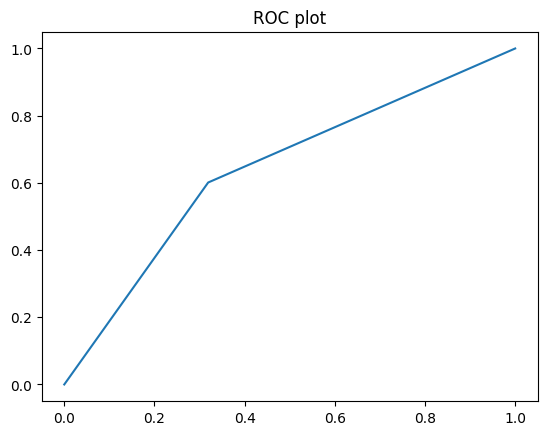

In [ ]:
#Visualizations and plotting  roc
fpr, tpr, threshold = roc_curve(y_test, predictions)

sns.lineplot(x=fpr, y=tpr,)

plt.title("ROC plot")